# 🚗 EV Market Analysis 2026
### By: Janvi Mehta | 1st Year AIML Student

## About This Project:
This notebook analyzes the 2026 Electric Vehicle dataset containing 103 EVs
across 16 features including price, range, speed, and efficiency.

**Goal:** Understand what factors influence EV pricing and performance.

**Dataset:** AI Learner Tech — EV Prices 2026 (Kaggle)

In [106]:
# Importing all libraries I'll need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully ✅")

All libraries loaded successfully ✅


In [80]:
# Load the dataset from uploaded zip file
df=pd.read_csv("/content/archive.zip", compression="zip")
# Confirms that it  load correctly- Checking rows and columns
print("Dataset loaded! with shape:", df.shape)


Dataset loaded! with shape: (103, 16)


In [81]:
df.head(15) #returns first 15 data items

,Brand,Model,AccelSec,TopSpeed_KmH,Range_Km,Efficiency_WhKm,FastCharge_KmH,RapidCharge,PowerTrain,PlugType,BodyStyle,Segment,Seats,PriceEuro,Price_Per_Range,Energy_Rating
0,Audi,e-tron 50 quattro,6.8,190,280,231,450,Yes,AWD,Type 2 CCS,SUV,E,5,67358,240.56,High Consumption
1,Tesla,Cybertruck Dual Motor,5.0,190,460,261,710,Yes,AWD,Type 2 CCS,Pickup,N,6,55000,119.57,High Consumption
2,Nissan,Ariya 87kWh,7.6,160,440,198,520,Yes,FWD,Type 2 CCS,Hatchback,C,5,50000,113.64,Average
3,Porsche,Taycan 4S,4.0,250,365,195,730,Yes,AWD,Type 2 CCS,Sedan,F,4,102945,282.04,Average
4,Audi,e-tron Sportback 55 quattro,5.7,200,380,228,610,Yes,AWD,Type 2 CCS,SUV,E,5,81639,214.84,High Consumption
5,Tesla,Model S Long Range,3.8,250,515,184,560,Yes,AWD,Type 2,Liftback,F,5,79990,155.32,Average
6,Audi,e-tron S 55 quattro,4.5,210,320,270,510,Yes,AWD,Type 2 CCS,SUV,E,5,93800,293.12,High Consumption
7,Kia,e-Soul 64 kWh,7.9,167,365,175,340,Yes,FWD,Type 2 CCS,SUV,B,5,36837,100.92,Efficient
8,Mercedes,EQC 400 4MATIC,5.1,180,370,216,440,Yes,AWD,Type 2 CCS,SUV,D,5,69484,187.79,High Consumption
9,Tesla,Model 3 Long Range Dual Motor,4.6,233,450,161,940,Yes,AWD,Type 2 CCS,Sedan,D,5,55480,123.29,Very Efficient


## 🔍 Data Exploration
Getting a first look at the dataset — structure, column names, data types and basic statistics.

In [83]:
df.columns

Index(['Brand', 'Model', 'AccelSec', 'TopSpeed_KmH', 'Range_Km',
       'Efficiency_WhKm', 'FastCharge_KmH', 'RapidCharge', 'PowerTrain',
       'PlugType', 'BodyStyle', 'Segment', 'Seats', 'PriceEuro',
       'Price_Per_Range', 'Energy_Rating'],
      dtype='object')

In [84]:
df.info()# Checking dtypes, missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            103 non-null    object 
 1   Model            103 non-null    object 
 2   AccelSec         103 non-null    float64
 3   TopSpeed_KmH     103 non-null    int64  
 4   Range_Km         103 non-null    int64  
 5   Efficiency_WhKm  103 non-null    int64  
 6   FastCharge_KmH   103 non-null    object 
 7   RapidCharge      103 non-null    object 
 8   PowerTrain       103 non-null    object 
 9   PlugType         103 non-null    object 
 10  BodyStyle        103 non-null    object 
 11  Segment          103 non-null    object 
 12  Seats            103 non-null    int64  
 13  PriceEuro        103 non-null    int64  
 14  Price_Per_Range  103 non-null    float64
 15  Energy_Rating    103 non-null    object 
dtypes: float64(2), int64(5), object(9)
memory usage: 13.0+ KB


In [86]:
df.describe() # Data distribution analysis

,AccelSec,TopSpeed_KmH,Range_Km,Efficiency_WhKm,Seats,PriceEuro,Price_Per_Range
count,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000
mean,7.396117,179.194175,338.786408,189.165049,4.883495,55811.563107,164.604466
std,3.017430,43.573030,126.014444,29.566839,0.795834,34134.665280,66.793056
min,2.100000,123.000000,95.000000,104.000000,2.000000,20129.000000,93.040000
25%,5.100000,150.000000,250.000000,168.000000,5.000000,34429.500000,116.285000
50%,7.300000,160.000000,340.000000,180.000000,5.000000,45000.000000,144.440000
75%,9.000000,200.000000,400.000000,203.000000,5.000000,65000.000000,189.845000
max,22.400000,410.000000,970.000000,273.000000,7.000000,215000.000000,482.080000


Checking for missing values

In [87]:
print("Missing values in each column:")
print(df.isnull().sum()) #counts and displays missing values
print("\nTotal missing values:", df.isnull().sum().sum())


Missing values in each column:
Brand              0
Model              0
AccelSec           0
TopSpeed_KmH       0
Range_Km           0
Efficiency_WhKm    0
FastCharge_KmH     0
RapidCharge        0
PowerTrain         0
PlugType           0
BodyStyle          0
Segment            0
Seats              0
PriceEuro          0
Price_Per_Range    0
Energy_Rating      0
dtype: int64

Total missing values: 0


Checking and hence removing duplicates

In [89]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (103, 16)


simplifying column names

In [90]:
df.columns = df.columns.str.strip()
df.columns=df.columns.str.lower()
df.columns=df. columns.str.replace(' ', '_')
print("Cleaned column names:", df.columns.tolist())

Cleaned column names: ['brand', 'model', 'accelsec', 'topspeed_kmh', 'range_km', 'efficiency_whkm', 'fastcharge_kmh', 'rapidcharge', 'powertrain', 'plugtype', 'bodystyle', 'segment', 'seats', 'priceeuro', 'price_per_range', 'energy_rating']


In [ ]:
# changing fastcharge_kmh datatype to numeric
df['fastcharge_kmh'] = pd.to_numeric(df['fastcharge_kmh'], errors='coerce')

Cleaned data- summary

In [91]:
print("✅ Data Quality Summary")
print(f"Total Rows     : {df.shape[0]}")
print(f"Total Columns  : {df.shape[1]}")
print(f"Missing Values : {df.isnull().sum().sum()}")
print(f"Duplicate Rows : {df.duplicated().sum()}")
print("Dataset is clean — no action needed.")

✅ Data Quality Summary
Total Rows     : 103
Total Columns  : 16
Missing Values : 0
Duplicate Rows : 0
Dataset is clean — no action needed.


Questions I want to answer:
1. Which brands have the most EVs in the market?
2. What is the price distribution — are most EVs affordable or luxury?
3. Which brand is the most expensive on average?
4. Does battery range affect price?
5. Which brand offers the best range for the price?

1. Which brands appears the most?

In [92]:
top_brands = df['brand'].value_counts().head(10)
print(top_brands)

brand
Tesla          13
Audi            9
Nissan          8
Volkswagen      8
Skoda           6
Porsche         5
Renault         5
Kia             5
BMW             4
Ford            4
Name: count, dtype: int64


Chart 1 — Top 10 Brands by count (Bar Chart)

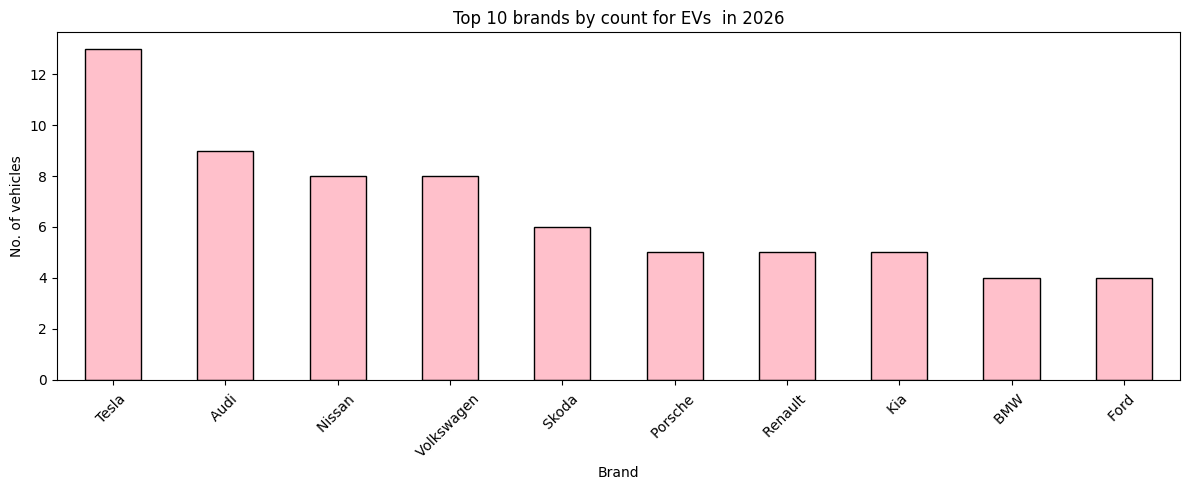

In [93]:
plt.figure(figsize=(12,5))
top_brands.plot(kind='bar', color='pink', edgecolor='black')
plt.title("Top 10 brands by count for EVs  in 2026")
plt.xlabel('Brand')
plt.ylabel('No. of vehicles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** Tesla leads the 2026 EV market with 13 models —
nearly 50% more than the second-placed Audi (9 models),
reflecting their dominant product lineup.

2. Price distribution

In [94]:
print("Average EV Price:", df['priceeuro'].mean().round(2))
print("Cheapest EV:", df['priceeuro'].min())
print("Most Expensive EV:", df['priceeuro'].max())
print("Median Price:", df['priceeuro'].median())

Average EV Price: 55811.56
Cheapest EV: 20129
Most Expensive EV: 215000
Median Price: 45000.0


Chart 2 — Price Distribution (Histogram)

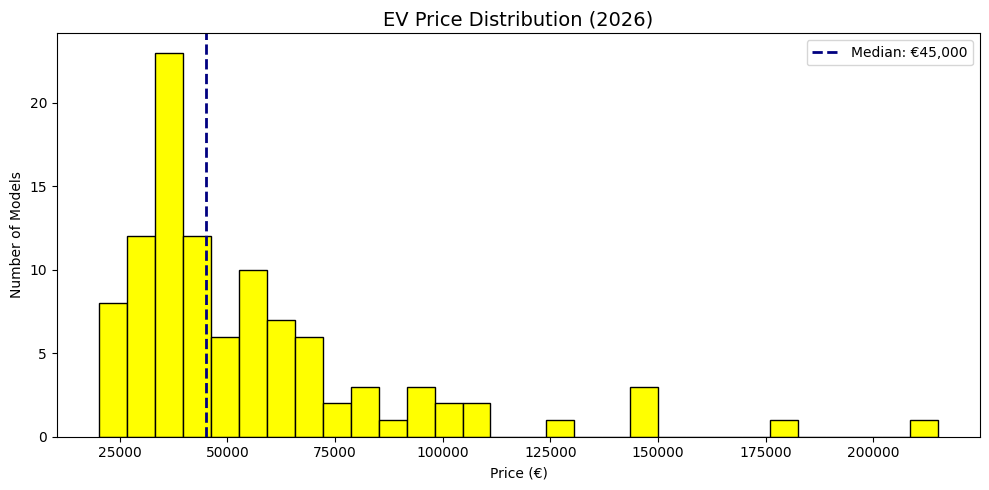

In [107]:
plt.figure(figsize=(10, 5))
plt.hist(df['priceeuro'], bins=30, color="yellow", edgecolor="black")
plt.axvline(df['priceeuro'].median(), color='navy', linestyle='--',
            linewidth=2,label=f"Median: €{df['priceeuro'].median():,.0f}")
plt.title('EV Price Distribution (2026)', fontsize=14)
plt.xlabel('Price (€)')
plt.ylabel('Number of Models')
plt.legend()
plt.tight_layout()
plt.show()


**Observation :** In the wide price range of €20,000- €215000 median comes at €45000

3. Most expensive brand on average

In [96]:
brand_avg_price = df.groupby('brand')['priceeuro'].mean().sort_values(ascending=False).head(10)
print(brand_avg_price)

brand
Lightyear     149000.000000
Porsche       138265.800000
Lucid         105000.000000
Audi           80593.666667
Tesla          80272.307692
Jaguar         75351.000000
Mercedes       61705.000000
Volvo          60437.000000
Byton          59833.333333
Polestar       56440.000000
Name: priceeuro, dtype: float64


Chart 3 — Average Price by Brand (Horizontal Bar)

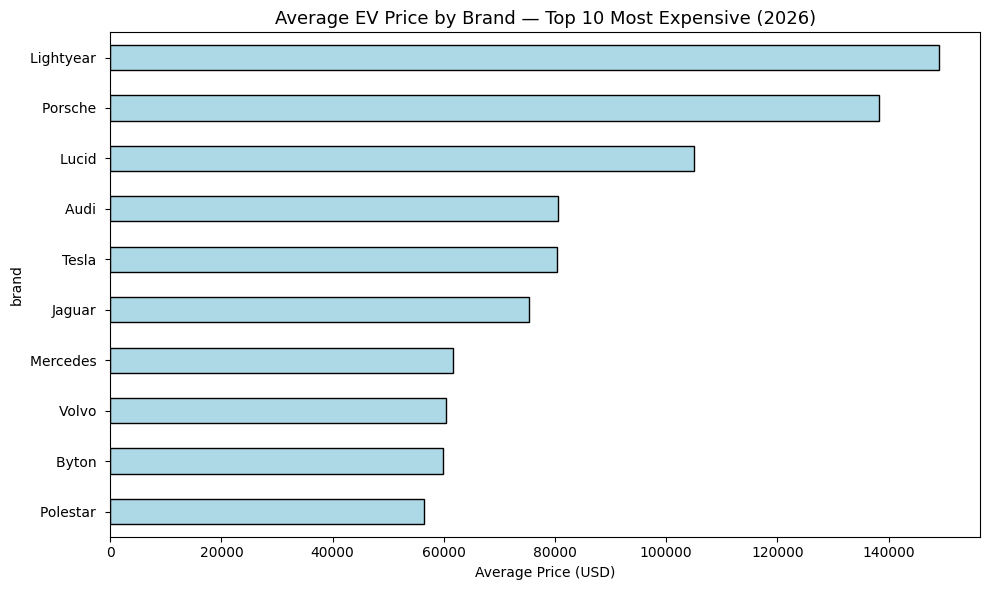

In [97]:
plt.figure(figsize=(10, 6))
brand_avg_price.sort_values().plot(kind='barh', color='lightblue', edgecolor='black')
plt.title('Average EV Price by Brand — Top 10 Most Expensive (2026)', fontsize=13)
plt.xlabel('Average Price (€)')
plt.tight_layout()
plt.show()

**Observation:** Lightyear is found to be the most exensive of all brands, priced at €1400000 while Polestar is the least expensive priced at nearly €57500

4.Correlation between range and  price

In [98]:
correlation = df['range_km'].corr(df['priceeuro'])
print(f"Correlation between range and price: {correlation:.2f}")

Correlation between range and price: 0.67


Chart 4 — Correlation Heatmap

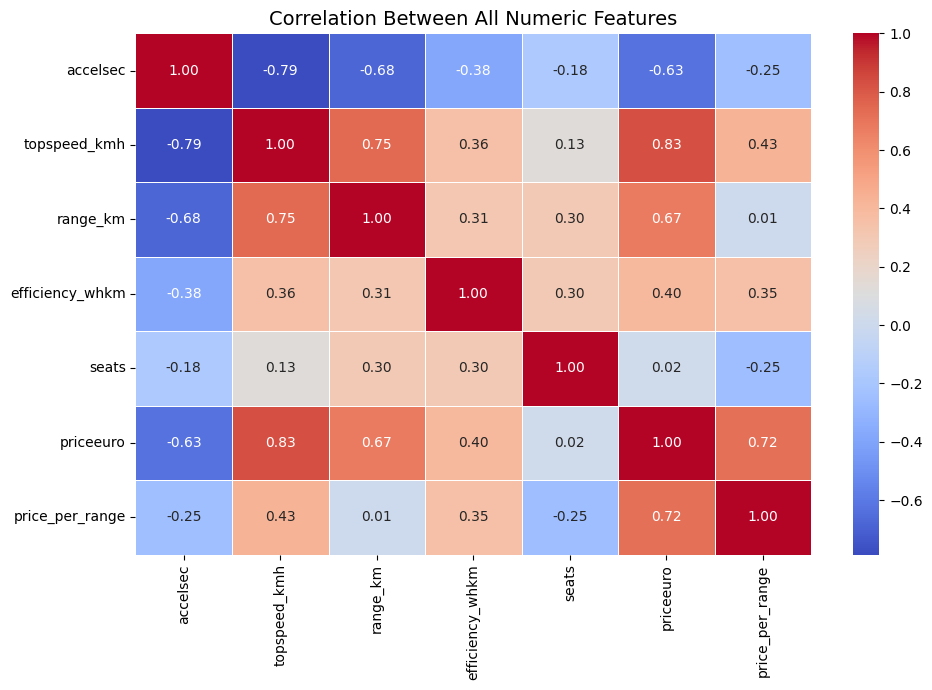

In [99]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between All Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

**Observation:**
The heatmap reveals that Range_Km and PriceEuro share the strongest
positive correlation (0.67) among all features — meaning range is
the single biggest spec-based driver of price.


5. Best range per dollar (value for money)

In [100]:
df['range_per_1000eur'] = df['range_km'] / (df['priceeuro'] / 1000)
best_value = df[['brand', 'model', 'priceeuro', 'range_km', 'range_per_1000eur']]\
             .sort_values('range_per_1000eur', ascending=False).head(10)
print(best_value)

           brand                 model  priceeuro  range_km  range_per_1000usd
26   Volkswagen             ID.3 Pro S      40936       440          10.748485
19   Volkswagen               ID.3 Pro      33000       350          10.606061
21        Skoda            Enyaq iV 80      40000       420          10.500000
79      Renault          Zoe ZE50 R110      31184       315          10.101334
17        Tesla   Cybertruck Tri Motor      75000       750          10.000000
100         Kia          e-Soul 64 kWh      36837       365           9.908516
7           Kia          e-Soul 64 kWh      36837       365           9.908516
18      Hyundai   Kona Electric 64 kWh      40795       400           9.805123
11          Kia          e-Niro 64 kWh      38105       370           9.710012
24         SEAT          Mii Electric       20129       195           9.687516


Chart- 5 — Range vs Price (Scatter Plot)


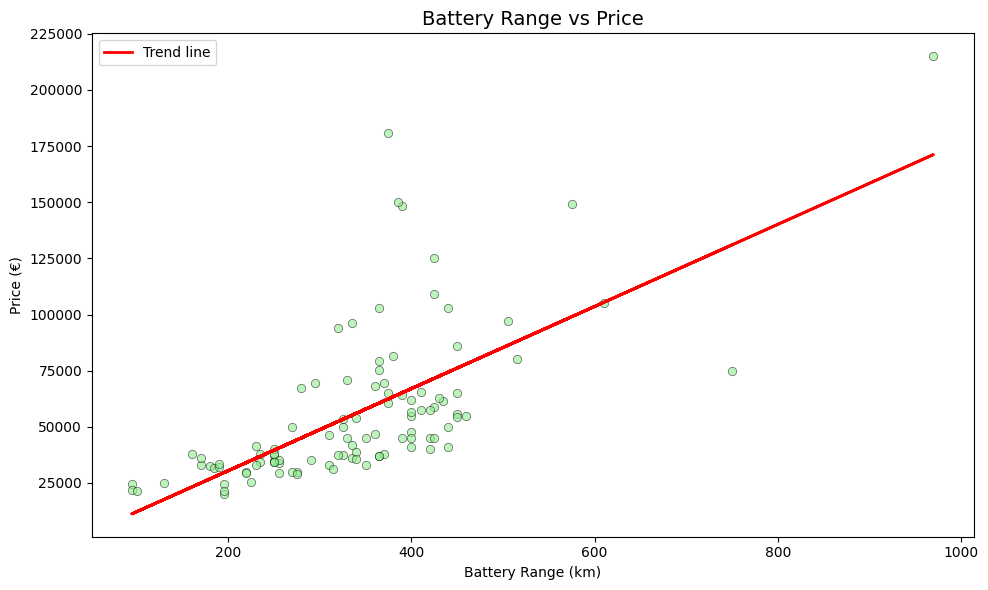

In [108]:
plt.figure(figsize=(10, 6))
plt.scatter(df['range_km'],df['priceeuro'], alpha=0.6, color='lightgreen',edgecolor='black', linewidths=0.5)
plt.title('Battery Range vs Price', fontsize=14)
plt.xlabel('Battery Range (km)')
plt.ylabel('Price (€)')
plt.tight_layout()
m, b = np.polyfit(df['range_km'], df['priceeuro'], 1)
plt.plot(df['range_km'], m*df['range_km'] + b, color='red', linewidth=2, label='Trend line')
plt.legend()
plt.show()

**Observation:**
The scatter plot visually confirms the 0.67 correlation — there is a
clear upward trend, meaning higher range EVs generally cost more.

The cluster of most dots between 200–500 km and €20,000–€80,000
confirms that this is where the mainstream EV market lives in 2026.

## Key Findings

1. **Market Leaders:** Tesla dominates with the most models available in 2026
2. **Price Range:** Most EVs fall between €20,000 - €110,000, with a median of €45,000

3. **Range & Price:** There is a moderate correlation of 0.67
   between battery range and price
4. **Best Value:** Volkswagen ID.3 Pro S  offers the best range per €1000 spent
5. **Most Premium Brand**:Lightyear has the best average price at €150,000

##**🏁 Conclusion**

The 2026 EVs dataset tells an interesting story. While brands like Lightyear and Porsche are priced at quite premium side but brands like Volkswagen, skoda and Renault driver, being at mid-range price, were found out to the best real-world value for money.
Tesla's dominance in model count (13 models) reflects a clear
strategy of market breadth, while the 0.67 range-price correlation
confirms that specs matter — but they don't tell the whole story.
